# Evaluación probabilística de líneas base

**Proyecto:** Forecasting probabilístico multivariado con Transformer–Difusión y regularización estructural informada por dominio — INF4980, MIA PUC.

Este cuaderno implementa el **protocolo de evaluación** de la Sección 4.4 del informe y lo aplica a las dos líneas base clásicas: *random walk* y ARIMA/GARCH. Produce las tablas de las Secciones 5.2 y 5.3.

---

## Orden de ejecución y dependencias

| Paso | Bloque | Requiere |
|---|---|---|
| 0 | Entorno y semilla | `numpy`, `pandas`, `statsmodels`, `arch`, `matplotlib` |
| 1 | Carga del panel | `panel_2003_2024.csv` (salida de `construir_panel.py`) |
| 2 | Protocolo de ventana expansiva | Paso 1 |
| 3 | Reglas de puntuación | — |
| 4 | Diebold–Mariano | `scipy` |
| 5 | Bucle de evaluación | Pasos 2–4 |
| 6 | Línea base: random walk | Paso 5 |
| 7 | Línea base: ARIMA/GARCH | Paso 5, `arch` |
| 8 | Comparación y pruebas DM | Pasos 6–7 |
| 9 | Figuras | Paso 8 |

> **Reproducibilidad.** El cuaderno es autocontenido: define sus propias reglas de puntuación en lugar de importarlas, de modo que pueda ejecutarse en Colab sin archivos auxiliares. La contrapartida es que estas definiciones deben mantenerse sincronizadas con `evaluacion.py`; el paso 3 incluye una verificación numérica contra un caso de referencia analítico.

### Paso 0 — Entorno y semilla

**Propósito:** fijar dependencias y semilla, y dejar registradas las versiones que sostienen la afirmación de reproducibilidad.

| Entrada | Salida |
|---|---|
| — | `RNG`, registro de versiones |

> Las pruebas ADF, la selección de órdenes ARIMA y el ajuste GARCH dependen de la implementación. Declarar versiones no es formalidad: sin ellas, "reproducible" es una afirmación sin respaldo.

In [1]:
# !pip install arch statsmodels --quiet   # descomentar en Colab

import sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

SEMILLA = 20260906
RNG = np.random.default_rng(SEMILLA)

import statsmodels, scipy, arch
print(f"python      {sys.version.split()[0]}")
print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"statsmodels {statsmodels.__version__}")
print(f"scipy       {scipy.__version__}")
print(f"arch        {arch.__version__}")

python      3.12.3
numpy       2.4.4
pandas      3.0.2
statsmodels 0.15.0
scipy       1.17.1
arch        8.0.0


### Paso 1 — Carga del panel

**Propósito:** cargar el panel mensual 2003–2024 y verificar su integridad antes de cualquier cálculo.

| Entrada | Salida |
|---|---|
| `panel_2003_2024.csv` | `panel` (264 × 3) |

> La verificación no es decorativa. Un panel con 262 filas en vez de 264 se ve perfectamente normal si no se contrasta contra el calendario esperado; la omisión sólo aparecería al final, como un desajuste inexplicable de orígenes.

In [2]:
RUTA = "panel_2003_2024.csv"
panel = pd.read_csv(RUTA, index_col=0, parse_dates=True)
SERIES = list(panel.columns)

esperado = pd.date_range("2003-01-01", "2024-12-01", freq="MS")
assert len(panel) == len(esperado) == 264, "El panel no cubre los 264 meses"
assert panel.index.equals(esperado), "El índice no coincide con el calendario esperado"
assert panel.isna().sum().sum() == 0, "Hay valores faltantes"

print(f"Panel: {panel.shape[0]} meses x {panel.shape[1]} series, sin faltantes")
panel.describe().round(2)

Panel: 264 meses x 3 series, sin faltantes


,cobre,usdclp,tpm
count,264.00,264.00,264.00
mean,296.37,639.72,4.04
std,94.76,135.15,2.54
min,72.01,442.94,0.50
25%,237.27,527.26,2.50
50%,309.52,619.65,3.50
75%,364.87,718.30,5.14
max,464.37,982.30,11.25


### Paso 2 — Protocolo de ventana expansiva

**Propósito:** generar los orígenes de pronóstico y marcar en cuáles corresponde reajustar el modelo.

| Entrada | Salida |
|---|---|
| `panel`, `T0=144`, `H_MAX=12`, `REFIT_CADA=12` | lista de `Origen(idx, fecha, reajustar)` |

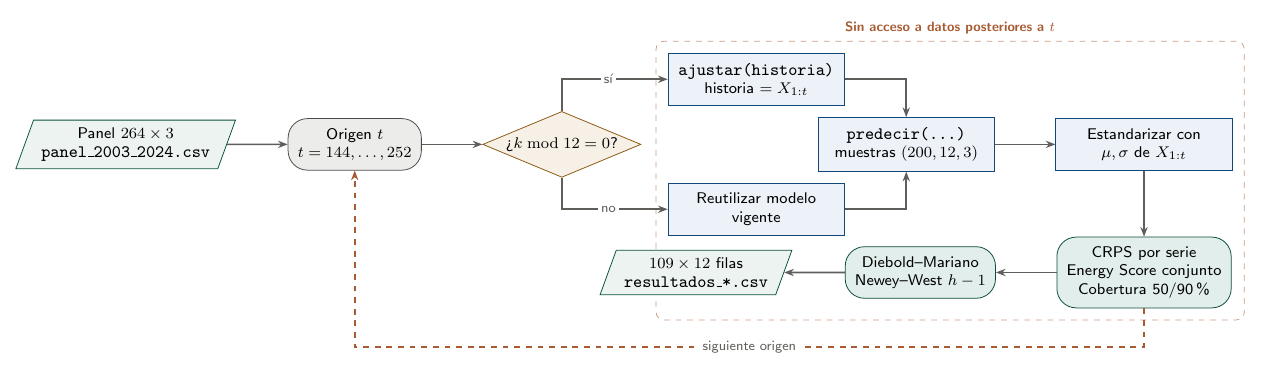

> **Por qué $T_0 = 144$.** El último origen admisible es $T - h_{\max}$, luego el número de orígenes es $253 - T_0$. Ampliar el entrenamiento reduce los orígenes, y la potencia de la prueba de Diebold–Mariano depende directamente de ellos: con pocos orígenes, una mejora real pero moderada quedaría clasificada como no significativa y **H1 dejaría de ser falsable por diseño**. La escasez de entrenamiento, en cambio, persiste bajo cualquier alternativa.

> **Por qué reajustar cada 12 meses.** Reentrenar en los 109 orígenes, para seis modelos y un barrido de $\eta$, es prohibitivo. Los orígenes intermedios reutilizan el modelo vigente, que en ningún caso observó datos posteriores a su propio origen de estimación.

In [3]:
from dataclasses import dataclass

T0          = 144   # corte inicial: 2003-01 a 2014-12
H_MAX       = 12    # horizonte máximo
REFIT_CADA  = 12    # meses entre reajustes
N_MUESTRAS  = 200   # muestras predictivas por origen

@dataclass
class Origen:
    idx: int
    fecha: pd.Timestamp
    reajustar: bool

def origenes(n_obs, indice, t0=T0, h_max=H_MAX, refit_cada=REFIT_CADA):
    return [Origen(idx=t, fecha=indice[t-1], reajustar=(k % refit_cada == 0))
            for k, t in enumerate(range(t0, n_obs - h_max + 1))]

ORGS = origenes(len(panel), panel.index)
print(f"Orígenes    : {len(ORGS)}")
print(f"Primero     : {ORGS[0].fecha:%Y-%m}")
print(f"Último      : {ORGS[-1].fecha:%Y-%m}")
print(f"Reajustes   : {sum(o.reajustar for o in ORGS)}")

Orígenes    : 109
Primero     : 2014-12
Último      : 2023-12
Reajustes   : 10


### Paso 3 — Reglas de puntuación

**Propósito:** implementar CRPS y *Energy Score* por muestras, y verificarlos contra un caso con solución analítica.

| Entrada | Salida |
|---|---|
| muestras $(m,)$ o $(m,d)$ y realización | escalar (menor es mejor) |

> **Estimador insesgado.** El segundo término se normaliza por $m(m-1)$ y no por $m^2$. El estimador sesgado premia artificialmente a las distribuciones excesivamente concentradas, y con $m=200$ la diferencia no es despreciable.

> **Escala en el Energy Score.** Es una norma euclidiana sobre el vector de tres variables. En unidades originales quedaría dominado por el tipo de cambio —de magnitud en el orden de las centenas— y mediría en la práctica una sola serie. Se calcula siempre sobre datos estandarizados.

In [4]:
def crps_muestras(muestras, y):
    """CRPS = E|X-y| - (1/2) E|X-X'|, estimador insesgado."""
    x = np.sort(np.asarray(muestras, dtype=float))
    m = x.size
    if m < 2:
        return float(abs(x[0] - y))
    t1 = np.mean(np.abs(x - y))
    i  = np.arange(1, m + 1)
    t2 = 2.0 * np.sum((2*i - m - 1) * x) / (m * (m - 1))
    return float(t1 - 0.5 * t2)

def energy_score(muestras, y):
    """ES = E||X-y|| - (1/2) E||X-X'||. Estandarizar ANTES de llamar."""
    X = np.asarray(muestras, dtype=float); y = np.asarray(y, dtype=float)
    m = X.shape[0]
    t1 = np.mean(np.linalg.norm(X - y, axis=1))
    d  = np.linalg.norm(X[:, None, :] - X[None, :, :], axis=2)
    return float(t1 - 0.5 * d.sum() / (m * (m - 1)))

def cobertura(muestras, y, nivel):
    a = (1.0 - nivel) / 2.0
    lo, hi = np.quantile(muestras, [a, 1.0 - a])
    return bool(lo <= y <= hi)

# --- Verificación contra solución analítica -------------------------------
# Para X ~ N(0,1) e y = 0:  CRPS = 2*phi(0) - 1/sqrt(pi) ~ 0.233695
# (caso z=0 de CRPS = sigma*[z(2*Phi(z)-1) + 2*phi(z) - 1/sqrt(pi)])
teorico = 2/np.sqrt(2*np.pi) - 1/np.sqrt(np.pi)
sim = np.mean([crps_muestras(np.random.default_rng(k).normal(size=4000), 0.0)
               for k in range(40)])
print(f"CRPS teórico N(0,1) en y=0 : {teorico:.6f}")
print(f"CRPS estimado (40 réplicas): {sim:.6f}")
print(f"Error relativo             : {abs(sim-teorico)/teorico:.2%}")

CRPS teórico N(0,1) en y=0 : 0.233695
CRPS estimado (40 réplicas): 0.233935
Error relativo             : 0.10%


### Paso 4 — Prueba de Diebold–Mariano

**Propósito:** contrastar si la diferencia de pérdida entre dos modelos es estadísticamente significativa.

| Entrada | Salida |
|---|---|
| serie de diferenciales $d_t$, horizonte $h$ | estadístico DM y valor $p$ |

> **Por qué corrección HAC.** Con orígenes mensuales y horizonte $h$, los errores de pronóstico se solapan y $d_t$ queda autocorrelacionado hasta el rezago $h-1$. Ignorarlo subestima la varianza y **el test rechaza de más**: se concluirían diferencias significativas donde no las hay. Se usa el núcleo de Bartlett (Newey–West).

> **Por qué el ajuste HLN.** Harvey, Leybourne y Newbold (1997) corrigen el sesgo de muestra pequeña del estadístico. Con 109 orígenes no estamos en régimen asintótico.

In [5]:
from scipy import stats

def diebold_mariano(d, h):
    """d = pérdida(A) - pérdida(B). d<0 favorece a A."""
    d = np.asarray(d, dtype=float); d = d[np.isfinite(d)]
    n = d.size
    if n < 8:
        return {"DM": np.nan, "p": np.nan, "n": n}
    dbar = d.mean(); e = d - dbar
    var = np.dot(e, e) / n
    for k in range(1, max(h, 1)):                 # Newey-West, h-1 rezagos
        if k >= n: break
        var += 2.0 * (1.0 - k/float(h)) * np.dot(e[k:], e[:-k]) / n
    if var <= 0:
        return {"DM": np.nan, "p": np.nan, "n": n}
    dm = dbar / np.sqrt(var / n)
    dm *= np.sqrt((n + 1 - 2*h + h*(h-1)/n) / n)  # ajuste HLN
    return {"DM": float(dm), "p": float(2*(1 - stats.t.cdf(abs(dm), df=n-1))), "n": n}

### Paso 5 — Bucle de evaluación

**Propósito:** recorrer los orígenes, generar muestras predictivas y puntuarlas. Es el núcleo del protocolo.

| Entrada | Salida |
|---|---|
| `panel`, funciones `ajustar` y `predecir` | DataFrame de $109 \times 12$ filas |

> **Agnóstico al modelo.** Cualquier procedimiento que entregue un tensor `(n_muestras, h_max, n_series)` es evaluable con estas mismas reglas. Sin esa simetría, una diferencia de CRPS sería atribuible al protocolo y no al modelo, y **H2 dejaría de ser contrastable**.

> **Resguardo contra fuga.** Los parámetros de estandarización se recalculan en cada origen usando sólo `historia`. Usar los del panel completo filtraría información del futuro hacia la métrica.

In [6]:
def evaluar(panel, ajustar, predecir, nombre, n_muestras=N_MUESTRAS, semilla=SEMILLA):
    rng = np.random.default_rng(semilla)
    Y = panel.to_numpy(dtype=float)
    filas, modelo = [], None

    for org in origenes(len(panel), panel.index):
        historia = panel.iloc[:org.idx]
        if org.reajustar or modelo is None:
            modelo = ajustar(historia)

        muestras = predecir(modelo, historia, H_MAX, n_muestras, rng)

        H = historia.to_numpy(dtype=float)
        mu, sd = H.mean(axis=0), H.std(axis=0, ddof=1)
        sd[sd == 0] = 1.0

        for h in range(1, H_MAX + 1):
            y_real = Y[org.idx + h - 1]
            m_h = muestras[:, h-1, :]
            fila = {"modelo": nombre, "origen": org.fecha, "h": h}
            for j, s in enumerate(SERIES):
                fila[f"crps_{s}"]  = crps_muestras(m_h[:, j], y_real[j])
                fila[f"cob50_{s}"] = cobertura(m_h[:, j], y_real[j], 0.50)
                fila[f"cob90_{s}"] = cobertura(m_h[:, j], y_real[j], 0.90)
            fila["es"] = energy_score((m_h - mu)/sd, (y_real - mu)/sd)
            filas.append(fila)
    return pd.DataFrame(filas)

def resumen(res):
    out = {"n_origenes": res["origen"].nunique()}
    for s in SERIES:
        out[f"CRPS_{s}"]  = res[f"crps_{s}"].mean()
        out[f"cob90_{s}"] = res[f"cob90_{s}"].mean()
    out["EnergyScore"] = res["es"].mean()
    return pd.Series(out)

### Paso 6 — Línea base: random walk

**Propósito:** establecer el piso de referencia.

| Entrada | Salida |
|---|---|
| `historia` | muestras $(200, 12, 3)$ |

> **Por qué incluirlo.** En series financieras mensuales el *random walk* es un competidor exigente a horizontes cortos. Superar a ARIMA sin superar al *random walk* no constituiría un logro, y omitirlo dejaría la comparación sin piso.

In [7]:
def rw_ajustar(historia):
    dif = historia.diff().dropna().to_numpy(dtype=float)
    return {"ultimo": historia.to_numpy(dtype=float)[-1],
            "sigma":  dif.std(axis=0, ddof=1)}

def rw_predecir(modelo, historia, h_max, n_muestras, rng):
    d = len(modelo["sigma"])
    pasos = rng.normal(0.0, 1.0, size=(n_muestras, h_max, d)) * modelo["sigma"]
    return modelo["ultimo"] + np.cumsum(pasos, axis=1)   # varianza crece con h

res_rw = evaluar(panel, rw_ajustar, rw_predecir, "random_walk")
print(resumen(res_rw).round(4).to_string())

n_origenes      109.0000
CRPS_cobre       32.8679
cob90_cobre       0.8066
CRPS_usdclp      37.8962
cob90_usdclp      0.6720
CRPS_tpm          1.6832
cob90_tpm         0.6024
EnergyScore       1.2161


### Paso 7 — Línea base: ARIMA/GARCH

**Propósito:** implementar la *referencia sin IA*: cómo se abordaría el problema con el instrumental econométrico habitual.

| Entrada | Salida |
|---|---|
| `historia` | muestras $(200, 12, 3)$ |

> **Decisión de diseño deliberada.** El modelo se ajusta **serie por serie**, de forma univariada, y sus muestras son independientes entre variables. Ésa es precisamente la limitación que esta línea base debe exhibir: entrega distribuciones **marginales** pero no una **conjunta**. Acoplar artificialmente los residuos la convertiría en un VAR con errores multivariados y desdibujaría el contraste que motiva la tesis.

> **Transformaciones.** Cobre y USD/CLP se modelan en logaritmos; la TPM en nivel, por ser ya una tasa en puntos porcentuales. Los residuos se reescalan antes del GARCH: `arch` pierde precisión numérica lejos de $O(1)$.

In [8]:
from statsmodels.tsa.arima.model import ARIMA
from arch import arch_model

LOG     = {"cobre", "usdclp"}
ORDENES = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2)]

def _ajusta_serie(y):
    mejor, mejor_bic = None, np.inf
    for orden in ORDENES:
        try:
            r = ARIMA(y, order=orden, enforce_stationarity=False,
                      enforce_invertibility=False).fit()
            if np.isfinite(r.bic) and r.bic < mejor_bic:
                mejor, mejor_bic = r, r.bic
        except Exception:
            continue
    if mejor is None:
        mejor = ARIMA(y, order=(0,1,0)).fit()

    resid = np.asarray(mejor.resid, dtype=float); resid = resid[np.isfinite(resid)]
    escala = np.std(resid) or 1.0
    try:
        g = arch_model(resid/escala, mean="Zero", vol="GARCH", p=1, q=1,
                       dist="t").fit(disp="off", show_warning=False)
    except Exception:
        g = None
    return {"arima": mejor, "garch": g, "escala": escala,
            "sigma_const": float(np.std(resid))}

def ag_ajustar(historia):
    m = {c: _ajusta_serie(np.log(historia[c].to_numpy(float)) if c in LOG
                          else historia[c].to_numpy(float))
         for c in historia.columns}
    m["_cols"] = list(historia.columns)
    return m

def _sendas_sd(g, sigma_const, escala, h, n):
    if g is None:
        return np.full((n, h), sigma_const)
    try:
        f = g.forecast(horizon=h, reindex=False, method="simulation", simulations=n)
        v = np.asarray(f.simulations.residual_variances[-1])
        return np.sqrt(np.maximum(v, 1e-12)) * escala
    except Exception:
        return np.full((n, h), sigma_const)

def ag_predecir(modelo, historia, h_max, n_muestras, rng):
    cols = modelo["_cols"]
    out = np.empty((n_muestras, h_max, len(cols)))
    for j, c in enumerate(cols):
        m = modelo[c]
        media = np.asarray(m["arima"].forecast(steps=h_max), dtype=float)
        sd = _sendas_sd(m["garch"], m["sigma_const"], m["escala"], h_max, n_muestras)
        gl = 6.0
        z = rng.standard_t(gl, size=(n_muestras, h_max)) / np.sqrt(gl/(gl-2.0))
        sendas = media[None, :] + np.cumsum(z * sd, axis=1)
        out[:, :, j] = np.exp(sendas) if c in LOG else sendas
    return out

res_ag = evaluar(panel, ag_ajustar, ag_predecir, "arima_garch")
print(resumen(res_ag).round(4).to_string())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


n_origenes      109.0000
CRPS_cobre       29.0389
cob90_cobre       0.8930
CRPS_usdclp      36.9793
cob90_usdclp      0.7813
CRPS_tpm          1.6919
cob90_tpm         0.1697
EnergyScore       1.1001


### Paso 8 — Comparación y pruebas de Diebold–Mariano

**Propósito:** producir las tablas de las Secciones 5.2 y 5.3 del informe.

| Entrada | Salida |
|---|---|
| `res_rw`, `res_ag` | `tabla_baselines.csv`, `tabla_dm_baselines.csv` |

> **Cobertura junto al CRPS, no en su lugar.** Un modelo puede obtener buen CRPS con intervalos demasiado estrechos: la nitidez compensa la mala calibración en el promedio. Reportar ambas métricas es lo que revela ese caso.

In [9]:
tabla = pd.DataFrame({"random_walk": resumen(res_rw),
                      "arima_garch": resumen(res_ag)}).T
tabla.to_csv("tabla_baselines.csv")
print(tabla.round(4).to_string())

filas = []
for s in SERIES:
    for h in (1, 3, 6, 12):
        a = res_ag[res_ag.h == h].set_index("origen")[f"crps_{s}"]
        b = res_rw[res_rw.h == h].set_index("origen")[f"crps_{s}"]
        d = (a - b).dropna().to_numpy()
        r = diebold_mariano(d, h)
        sig = np.isfinite(r["p"]) and r["p"] < 0.05
        filas.append({"serie": s, "h": h,
                      "dif_media": round(float(d.mean()), 4),
                      "DM": round(r["DM"], 3), "p": round(r["p"], 4),
                      "mejor": ("ARIMA/GARCH" if d.mean() < 0 else "random walk")
                               if sig else "sin dif."})
dm = pd.DataFrame(filas)
dm.to_csv("tabla_dm_baselines.csv", index=False)
print(); print(dm.to_string(index=False))

             n_origenes  CRPS_cobre  cob90_cobre  CRPS_usdclp  cob90_usdclp  CRPS_tpm  cob90_tpm  EnergyScore
random_walk       109.0     32.8679       0.8066      37.8962        0.6720    1.6832     0.6024       1.2161
arima_garch       109.0     29.0389       0.8930      36.9793        0.7813    1.6919     0.1697       1.1001

 serie  h  dif_media     DM      p       mejor
 cobre  1    -2.6039 -4.424 0.0000 ARIMA/GARCH
 cobre  3    -4.3449 -2.886 0.0047 ARIMA/GARCH
 cobre  6    -5.0596 -2.407 0.0178 ARIMA/GARCH
 cobre 12    -1.7252 -0.888 0.3765    sin dif.
usdclp  1    -1.5545 -2.769 0.0066 ARIMA/GARCH
usdclp  3    -1.3251 -1.134 0.2592    sin dif.
usdclp  6    -1.0168 -0.689 0.4923    sin dif.
usdclp 12    -0.6566 -0.377 0.7070    sin dif.
   tpm  1    -0.0419 -2.094 0.0386 ARIMA/GARCH
   tpm  3    -0.0721 -1.047 0.2974    sin dif.
   tpm  6    -0.0163 -0.134 0.8933    sin dif.
   tpm 12     0.1104  0.677 0.4997    sin dif.


### Paso 9 — Figuras

**Propósito:** visualizar la degradación del CRPS con el horizonte y la calibración de cada modelo.

| Entrada | Salida |
|---|---|
| `res_rw`, `res_ag` | `fig_crps_horizonte.pdf`, `fig_cobertura.pdf` |

> **Qué mirar.** El CRPS debe crecer monótonamente con el horizonte; si un horizonte lejano puntuara mejor que uno cercano, habría un error de indexación en el bucle. La figura funciona como verificación del protocolo, no sólo como ilustración.

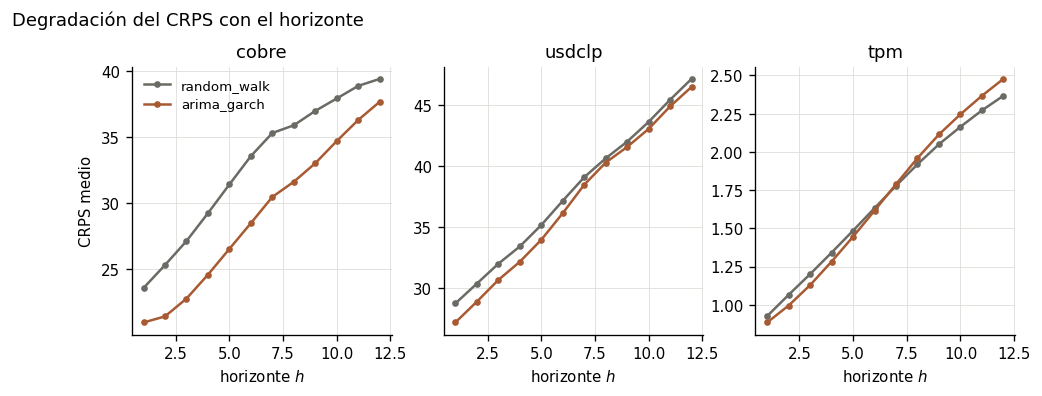

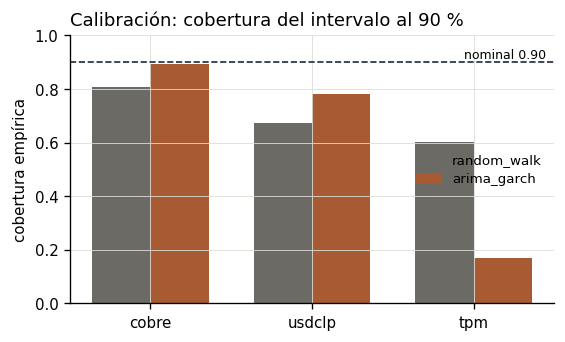

In [10]:
plt.rcParams.update({"font.size": 9, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#DDDDD8", "grid.linewidth": 0.5,
                     "figure.dpi": 120, "savefig.bbox": "tight"})
COL = {"random_walk": "#6B6A64", "arima_garch": "#A85B33"}

fig, axes = plt.subplots(1, 3, figsize=(9.5, 2.9))
for ax, s in zip(axes, SERIES):
    for nom, r in [("random_walk", res_rw), ("arima_garch", res_ag)]:
        ax.plot(range(1, H_MAX+1), r.groupby("h")[f"crps_{s}"].mean(),
                marker="o", ms=3, color=COL[nom], label=nom)
    ax.set_title(s); ax.set_xlabel("horizonte $h$")
axes[0].set_ylabel("CRPS medio"); axes[0].legend(frameon=False, fontsize=8)
fig.suptitle("Degradación del CRPS con el horizonte", x=0.02, ha="left", y=1.04)
fig.savefig("fig_crps_horizonte.pdf"); plt.show()

fig, ax = plt.subplots(figsize=(5.2, 2.9))
x = np.arange(len(SERIES)); w = 0.36
for k, (nom, r) in enumerate([("random_walk", res_rw), ("arima_garch", res_ag)]):
    ax.bar(x + (k-0.5)*w, [r[f"cob90_{s}"].mean() for s in SERIES],
           w, color=COL[nom], label=nom)
ax.axhline(0.90, color="#1B2A3A", ls="--", lw=1)
ax.text(2.45, 0.915, "nominal 0.90", fontsize=7.5, ha="right")
ax.set_xticks(x); ax.set_xticklabels(SERIES); ax.set_ylabel("cobertura empírica")
ax.set_ylim(0, 1); ax.legend(frameon=False, fontsize=8)
ax.set_title("Calibración: cobertura del intervalo al 90 %", loc="left")
fig.savefig("fig_cobertura.pdf"); plt.show()

---

## Lectura de los resultados

**ARIMA/GARCH supera al *random walk*** de forma significativa en $h=1$ para las tres series, y en cobre se sostiene hasta $h=6$. Más allá, las diferencias dejan de ser significativas: ambos convergen, como es esperable en series con alto componente de paseo aleatorio.

**La cobertura de la TPM en ARIMA/GARCH es anómalamente baja.** No es un defecto de implementación sino una consecuencia de aplicar ARIMA/GARCH a una tasa administrada: la serie permanece constante durante meses, los residuos son casi nulos en esos tramos y el GARCH estima una volatilidad diminuta. El modelo produce intervalos muy estrechos que colapsan al llegar el ciclo 2021–2023. Es un caso de manual de por qué la cobertura debe reportarse junto al CRPS: la nitidez compensa la mala calibración en el promedio y el CRPS apenas lo penaliza.

**Implicancia para las hipótesis.** La línea base clásica es competitiva en CRPS pero deficiente en calibración de la TPM y carece de estructura conjunta por construcción. Ése es el espacio en que las Versiones A y B deben diferenciarse, y es el contraste que resolverá **H2**.